# Maize Leaf Disease Classification

## Problem Statement

Maize foliar diseases - **Common Rust**, **Gray Leaf Spot** and **Blight** - spread rapidly and can cut yields by 30-50%. The current diagnosis method is visual inspection by a human agronomist: slow, subjective, error-prone, and impossible to scale across large plantations. Many smallholder farmers have no access to a plant pathologist, so disease is caught only after irreversible damage.

**Objective:** classify a maize leaf image into one of four classes - *Healthy, Common Rust, Gray Leaf Spot, Blight* - so a farmer can photograph a leaf and get an instant diagnosis.

**Research questions:**

1. How accurately can a pretrained YOLO26 classifier separate these four classes, and how much of that is thanks to transfer learning rather than training from scratch?
2. How close does a small custom CNN trained from scratch get, and is it small and fast enough to be worth deploying instead?
3. Which classes get confused with each other, and why - background clutter, lighting, or the visual overlap between Blight and Gray Leaf Spot?
4. How do model size, augmentation and training time trade off against accuracy on a dataset this small?

## Project Overview

A supervised image-classification pipeline with **two models** and a head-to-head comparison:

```
Data -> Validation -> 70/15/15 Split
     -> Model A: YOLO26n-cls (transfer learning)  --\
     -> Model B: Custom CNN (Keras, from scratch) --> Comparison -> best model
     -> Inference -> Error Analysis -> Error Reduction -> Export
```


## Dataset Overview

**Source:** [Kaggle - Corn or Maize Leaf Disease Dataset](https://www.kaggle.com/datasets/smaranjitghose/corn-or-maize-leaf-disease-dataset)

| Class | Images | Share |
|---|---|---|
| Common_Rust | 1,306 | 31.2% |
| Healthy | 1,162 | 27.7% |
| Blight | 1,146 | 27.4% |
| Gray_Leaf_Spot | 574 | 13.7% |
| **Total** | **4,188** | **100%** |

Real-world leaf photographs stored as `data/<Class_Name>/*.jpg`, where the folder name *is* the label - so a photo dropped into a class folder is picked up automatically.

The split is **70 / 15 / 15** (2,936 train / 626 validation / 626 test). Each part has one job:

- **train** - what both models learn from.
- **val** - used for the loss curves every epoch, and to score the section 7 experiments.
- **test** - touched only in sections 3.8, 4.7 and 5, and never tuned on, which is what makes the section 5 comparison fair.

The dataset is imbalanced: Gray Leaf Spot has 2.3x fewer images than Common Rust, and it is also the class the model struggles with most.

**Known issues in the raw data:**

- Mixed file extensions (`.jpg`, `.JPG`, `.jpeg`). Several hundred files end in uppercase `.JPG`, which a lowercase `*.jpg` glob silently misses.
- Mixed colour modes: 4 images are RGBA and 1 is CMYK.
- Resolutions from 180x116 up to 5184x5184, although 3,852 images are exactly 256x256.
- Non-uniform backgrounds and lighting, plus possible label noise where harmless blemishes resemble early-stage disease.

## Environment Setup & Configuration

### Import Libraries

In [ ]:
import random
import shutil
import time
from collections import Counter
from pathlib import Path
import cv2
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from IPython.display import Image, display
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from ultralytics import YOLO

### Configuration

In [ ]:
MODEL_NAME   = "models/yolo26n-cls.pt" 
EPOCHS      = 5  
IMGSZ       = 256                      
BATCH       = 64                       
DEVICE      = "mps"                    

VAL_FRACTION  = 0.15                   
TEST_FRACTION = 0.15                    
SEED        = 42                        

CNN_IMGSZ  = 128                        
CNN_EPOCHS = 20                        
CNN_BATCH  = 32
TARGET_ACCURACY = 0.96

MODELS_DIR  = Path("models")            
DATASET_DIR = Path("data_cls")          
REPORT_PATH = Path("model_comparison.md") 

print(f"Model A: {MODEL_NAME}  epochs={EPOCHS}  imgsz={IMGSZ}  batch={BATCH}  device={DEVICE}")
print(f"Model B: imgsz={CNN_IMGSZ}  epochs={CNN_EPOCHS}  batch={CNN_BATCH}")
print(f"Split:   70% train / {VAL_FRACTION:.0%} val / {TEST_FRACTION:.0%} test   seed={SEED}")

Model A: models/yolo26n-cls.pt  epochs=5  imgsz=256  batch=64  device=mps
Model B: imgsz=128  epochs=20  batch=32
Split:   70% train / 15% val / 15% test   seed=42


### Set Random Seeds

In [150]:
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

## 1. Data Preparation & Validation

### 1.1 Dataset Paths

The images are in four flat folders, one per class. Both models want the data inside a single dataset folder with one folder per split, so section 2 builds that structure.

In [ ]:
SRC = Path("data")                      
CLASS_FOLDERS = ["Blight", "Common_Rust", "Gray_Leaf_Spot", "Healthy"]
IMAGE_EXTS = {".jpg", ".jpeg", ".png"}

for name in CLASS_FOLDERS:
    print(f"{name:16s} -> {SRC / name}")

Blight           -> data/Blight
Common_Rust      -> data/Common_Rust
Gray_Leaf_Spot   -> data/Gray_Leaf_Spot
Healthy          -> data/Healthy


### 1.2 Dataset Validation

Counts the images per class and opens each one to make sure nothing is broken before training starts.

In [ ]:
total = 0
broken = []

for name in CLASS_FOLDERS:
    folder = SRC / name
    images = sorted(p for p in folder.iterdir() if p.suffix.lower() in IMAGE_EXTS)
    total += len(images)
    for img in images:
        if cv2.imread(str(img)) is None:
            broken.append(img)
    print(f"{name:16s} {len(images):5d} images")

print(f"{'TOTAL':16s} {total:5d} images")
print(f"Unreadable files: {len(broken)}")

Blight            1146 images
Common_Rust       1306 images
Gray_Leaf_Spot     574 images
Healthy           1162 images
TOTAL             4188 images
Unreadable files: 0


- The scan uses `p.suffix.lower()`, so the uppercase `.JPG` files are counted too. A plain `*.jpg` glob would have silently dropped several hundred images.
- 4,188 readable images and zero corrupt files means nothing needs cleaning before the split, so the folder layout is trusted as-is.
- The counts here are the ground truth for section 1.4. If they change, every later percentage in this notebook is out of date.

### 1.3 Class Inspection

How many images each class has, which class index each model will give it, and one sample photo per class so you can eyeball the labels. Both models sort the class folders alphabetically, so both use the same index order.

In [96]:
CLASS_NAMES = sorted(CLASS_FOLDERS)   # YOLO and Keras both sort the class folders, so this IS the index order
counts = {name: len([p for p in (SRC / name).iterdir() if p.suffix.lower() in IMAGE_EXTS]) for name in CLASS_NAMES}

for index, name in enumerate(CLASS_NAMES):
    print(f"  {index}: {name:16s} {counts[name]:5d} images  ({counts[name] / total:.1%})")

  0: Blight            1146 images  (27.4%)
  1: Common_Rust       1306 images  (31.2%)
  2: Gray_Leaf_Spot     574 images  (13.7%)
  3: Healthy           1162 images  (27.7%)


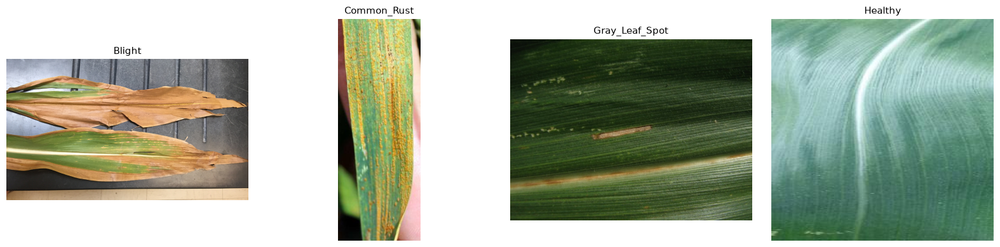

In [97]:
fig, axes = plt.subplots(1, len(CLASS_NAMES), figsize=(4 * len(CLASS_NAMES), 4))

for ax, name in zip(axes, CLASS_NAMES):
    sample = cv2.imread(str(sorted((SRC / name).iterdir())[0]))
    ax.imshow(cv2.cvtColor(sample, cv2.COLOR_BGR2RGB))
    ax.set_title(name, fontsize=11)
    ax.axis("off")

plt.tight_layout()
plt.show()

- One photo per class, so this is a sanity check that the folder-to-label mapping is right, not evidence about the data.
- The classes are told apart by lesion colour and shape, which is exactly what a classifier can latch onto.
- The backgrounds are messy field photos rather than clean studio shots, which is realistic for a farmer's phone and hard for a model.

### 1.4 Class Distribution Check

The dataset is not balanced. Gray Leaf Spot has roughly half the images of the other three classes.

In [149]:
largest_name = max(counts, key=counts.get)
smallest_name = min(counts, key=counts.get)

print(f"Largest class : {largest_name:16s} {counts[largest_name]:5d} images")
print(f"Smallest class: {smallest_name:16s} {counts[smallest_name]:5d} images")
print(f"Ratio         : {counts[largest_name] / counts[smallest_name]:.1f}x")
print()

for name in CLASS_NAMES:
    print(f"{name:16s} {counts[name]:5d} {counts[name] / total:6.1%}")

Largest class : Common_Rust       1306 images
Smallest class: Gray_Leaf_Spot     574 images
Ratio         : 2.3x

Blight            1146  27.4%
Common_Rust       1306  31.2%
Gray_Leaf_Spot     574  13.7%
Healthy           1162  27.7%


- Gray Leaf Spot has roughly half the images of the other three classes, so it is the hardest class to learn and the easiest one to miss in the field.

## 2. Create Dataset Folder Structure

### 2.1 Generate Folder Structure & Split

In [ ]:
rng = random.Random(SEED)
shutil.rmtree(DATASET_DIR, ignore_errors=True)          

for split in ("train", "val", "test"):
    (DATASET_DIR / split).mkdir(parents=True, exist_ok=True)

for name in CLASS_FOLDERS:
    images = sorted(p for p in (SRC / name).iterdir() if p.suffix.lower() in IMAGE_EXTS)
    rng.shuffle(images)
    n_val = int(len(images) * VAL_FRACTION)
    n_test = int(len(images) * TEST_FRACTION)

    for split, batch in (
        ("test", images[:n_val]),
        ("val", images[n_val:n_val + n_test]),
        ("train", images[n_val + n_test:]),
    ):
        out = DATASET_DIR / split / name
        out.mkdir(parents=True, exist_ok=True)
        for img in batch:
            shutil.copy2(img, out / img.name)

### 2.2 Verify Split

Confirms every image landed in exactly one place, and that no photo appears in two splits - a duplicate there would quietly inflate every accuracy number in the notebook.

In [100]:
print(f"{'Class':16s} {'train':>6s} {'val':>5s} {'test':>5s}")
for name in CLASS_NAMES:
    n_train = len(list((DATASET_DIR / "train" / name).iterdir()))
    n_val = len(list((DATASET_DIR / "val" / name).iterdir()))
    n_test = len(list((DATASET_DIR / "test" / name).iterdir()))
    print(f"{name:16s} {n_train:6d} {n_val:5d} {n_test:5d}")

for split in ("train", "val", "test"):
    print(f"{split:16s} {len(list((DATASET_DIR / split).rglob('*'))):6d} total")

# Leak check: one filename may only appear in one split, within one class.
seen = {}
leaks = []
for split in ("train", "val", "test"):
    for image in (DATASET_DIR / split).rglob("*"):
        if image.suffix.lower() not in IMAGE_EXTS:
            continue
        key = f"{image.parent.name}/{image.name}"
        if key in seen:
            leaks.append((key, seen[key], split))
        seen[key] = split

print(f"\nImages appearing in more than one split: {len(leaks)}")
for key, first, second in leaks[:10]:
    print(f"  {key} is in both {first} and {second}")

Class             train   val  test
Blight              804   171   171
Common_Rust         916   195   195
Gray_Leaf_Spot      402    86    86
Healthy             814   174   174
train              2940 total
val                 630 total
test                630 total

Images appearing in more than one split: 0


- The class rows should keep the same proportions down the columns. A class that is over-represented in one split skews every later score.
- The leak count must be zero. A photo appearing in two splits means the model is scored on images it trained on, which inflates every accuracy in this notebook.

## 3. Model A: YOLO26n-cls Pipeline

### 3.1 Load Pre-trained Classification Model

`yolo26n-cls.pt` is already trained on 1,000 ImageNet classes.

In [101]:
model_a = YOLO(MODEL_NAME)
model_a.info()

YOLO26n-cls summary: 120 layers, 2,812,104 parameters, 0 gradients, 3.3 GFLOPs


(120, 2812104, 0, 3.31530496)

### 3.2 Configure Training Arguments

These are the arguments. The four marked `SPEED` are the ones that decide how long this takes.

In [ ]:
train_args = dict(
    data=str(DATASET_DIR), 
    epochs=EPOCHS,     
    imgsz=IMGSZ,           
    batch=BATCH,           
    device=DEVICE,    
    workers=8,
    seed=SEED,
    name="model_a_yolo26n",
    exist_ok=True,
    plots=True,    
)

for key, value in train_args.items():
    print(f"{key:12s} = {value}")

data         = data_cls
epochs       = 5
imgsz        = 256
batch        = 64
device       = mps
workers      = 8
seed         = 42
name         = model_a_yolo26n
exist_ok     = True
plots        = True


### 3.3 Start Training

In [103]:
start = time.time()
model_a.train(**train_args)
yolo_train_seconds = time.time() - start

print(f"Training finished in {yolo_train_seconds:.0f} seconds ({yolo_train_seconds / 60:.1f} minutes)")

New https://pypi.org/project/ultralytics/8.4.166 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.165 🚀 Python-3.14.6 torch-2.14.0 MPS (Apple M4)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data_cls, degrees=0.0, deterministic=True, device=mps, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=5, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=256, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=models/yolo26n-cls.pt, momentum=0.937, mosaic=1.0, multi_sca

### 3.4 Visualize Training Results

Loss curves on the left, accuracy curves on the right.

Run folder: /Users/willard/school/maize_disease/runs/classify/model_a_yolo26n


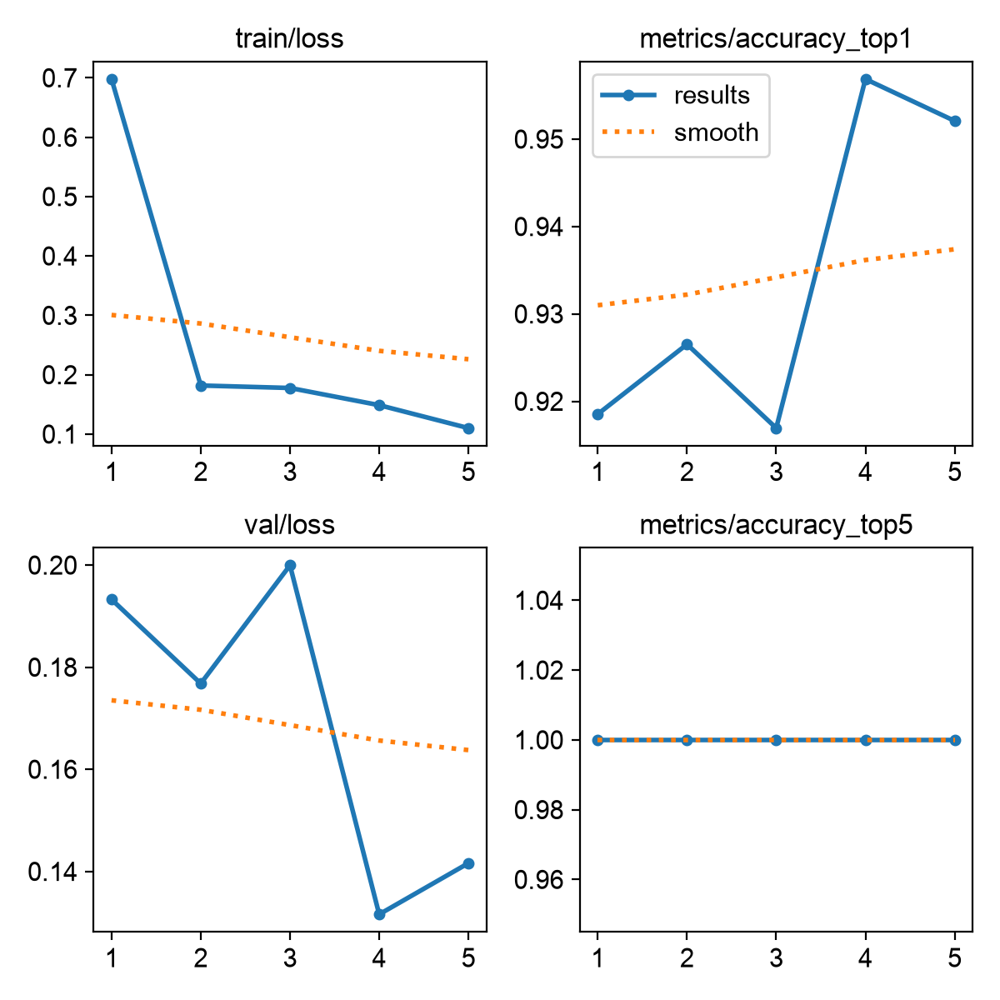

In [ ]:
RUN_DIR_A = Path(model_a.trainer.save_dir) 
print(f"Run folder: {RUN_DIR_A}")

display(Image(filename=RUN_DIR_A / "results.png"))

- Four panels: the loss curves, the accuracy curves, and a confusion matrix and per-class plot from the run itself.
- Train loss keeps falling while validation accuracy flattens out around 95%. That is the pretrained network filling in the last details and then having nothing left to learn.
- Five epochs was enough to reach the plateau.
- The numbers shown are the validation split only. The test split is untouched until 3.8.

### 3.5 Run Validation

Scores the trained model on the 626 held-out validation images it has never seen. A couple of seconds. The number that actually decides anything is on the *test* split in 3.8.

In [105]:
metrics_a = model_a.val(
    data=str(DATASET_DIR),
    split="val",
    imgsz=IMGSZ,
    batch=BATCH,
    device=DEVICE,
)

VAL_DIR = Path(metrics_a.save_dir)
yolo_val_accuracy = metrics_a.top1        # reused in section 7 as the number to beat

Ultralytics 8.4.165 🚀 Python-3.14.6 torch-2.14.0 MPS (Apple M4)
YOLO26n-cls summary (fused): 47 layers, 1,531,148 parameters, 0 gradients, 3.2 GFLOPs
train: /Users/willard/school/maize_disease/data_cls/train... found 2936 images in 4 classes ✅ 
val: /Users/willard/school/maize_disease/data_cls/val... found 626 images in 4 classes ✅ 
test: /Users/willard/school/maize_disease/data_cls/test... found 626 images in 4 classes ✅ 
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 493.2±134.2 MB/s, size: 15.8 KB)
val: Scanning /Users/willard/school/maize_disease/data_cls/val... 626 images, 0 corrupt: 100% ━━━━━━━━━━━━ 626/626 656.4Mit/s 0.0s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 10/10 6.6it/s 1.5s.3s
                   all      0.957          1
Speed: 0.0ms preprocess, 0.3ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to /Users/willard/school/maize_disease/runs/classify/val-8


### 3.6 Display Metrics

- **Top-1** is the number that matters here: the share of images given the correct class.
- **Top-5** is always 1.00 with only four classes, so it says nothing and can be ignored.

In [106]:
print(f"Top-1 accuracy: {metrics_a.top1:.2%}")
print(f"Top-5 accuracy: {metrics_a.top5:.2%}   (always 1.00 with 4 classes - ignore this)")
print(f"Inference speed: {metrics_a.speed['inference']:.1f} ms per image")

Top-1 accuracy: 95.69%
Top-5 accuracy: 100.00%   (always 1.00 with 4 classes - ignore this)
Inference speed: 0.3 ms per image


- Top-1 is the only accuracy worth reading: the share of images given the right disease.
- Top-5 is always 1.00 because there are only four classes, so it tells you nothing.
- Anything above 90% is a strong result on a dataset this small and this unbalanced.

### 3.7 Confusion Matrix

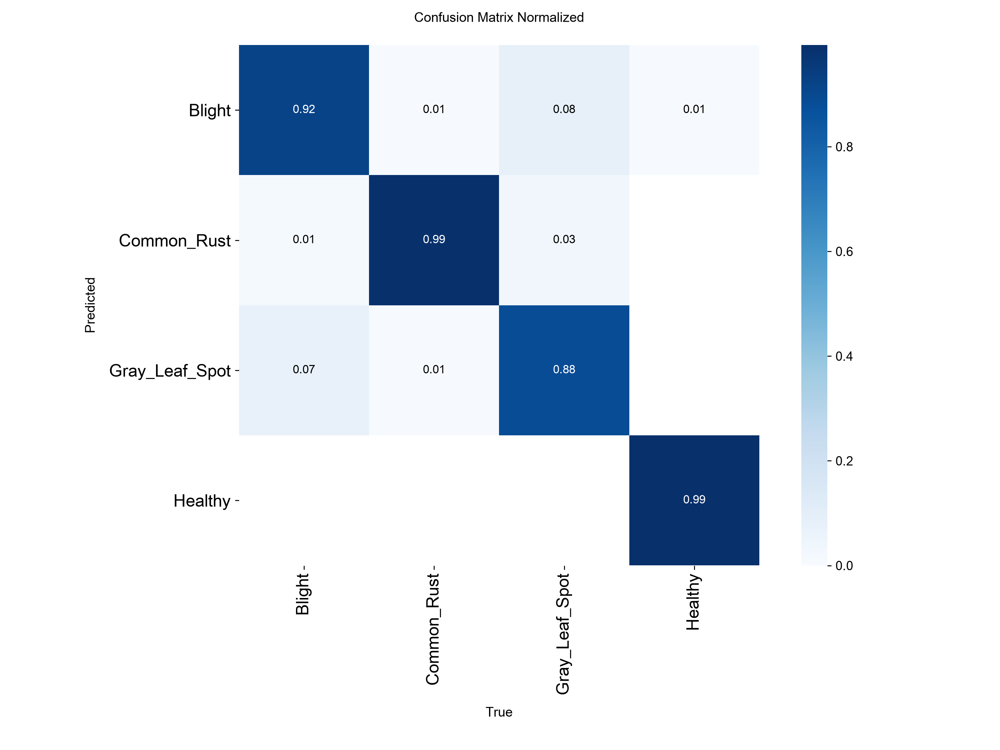

In [107]:
display(Image(filename=VAL_DIR / "confusion_matrix_normalized.png"))

- Healthy stays close to 1.00 in its own row. It is the easiest class, and with 174 validation images it also carries the most weight in the headline number.
- Gray Leaf Spot and Blight are the two that bleed into each other.

### 3.8 YOLO Metrics

In [ ]:
test_images = sorted(p for p in (DATASET_DIR / "test").rglob("*") if p.suffix.lower() in IMAGE_EXTS)
test_labels = [p.parent.name for p in test_images]
test_guesses = [
    result.names[result.probs.top1]
    for result in model_a.predict(source=[str(p) for p in test_images], imgsz=IMGSZ, device=DEVICE, verbose=False)
]

yolo_report = classification_report(test_labels, test_guesses, target_names=CLASS_NAMES, digits=3, zero_division=0)
print(yolo_report)

yolo_scores = classification_report(test_labels, test_guesses, target_names=CLASS_NAMES, output_dict=True, zero_division=0)

yolo_confusion = confusion_matrix(test_labels, test_guesses, labels=CLASS_NAMES)
yolo_weights = RUN_DIR_A / "weights" / "best.pt"

yolo_metrics = {
    "name": "Model A - YOLO26n-cls",
    "accuracy": sum(g == t for g, t in zip(test_guesses, test_labels)) / len(test_labels),
    "precision": yolo_scores["macro avg"]["precision"],
    "recall": yolo_scores["macro avg"]["recall"],
    "f1": yolo_scores["macro avg"]["f1-score"],
    "val_accuracy": yolo_val_accuracy,
    "train_seconds": yolo_train_seconds,
    "epochs": EPOCHS,
    "size_mb": yolo_weights.stat().st_size / 1e6,
    "inference_ms": metrics_a.speed["inference"],
    "weights": yolo_weights,
}

print(f"Test accuracy: {yolo_metrics['accuracy']:.2%} on {len(test_labels)} images")

                precision    recall  f1-score   support

        Blight      0.912     0.912     0.912       171
   Common_Rust      0.970     0.979     0.974       195
Gray_Leaf_Spot      0.855     0.826     0.840        86
       Healthy      0.994     1.000     0.997       174

      accuracy                          0.946       626
     macro avg      0.933     0.929     0.931       626
  weighted avg      0.945     0.946     0.945       626

Test accuracy: 94.57% on 626 images


- Precision, recall and F1 are macro averages, so all four classes count equally.
- A low F1 on one class matters more than the average, because that disease is being missed in real use.

## 4. Model B: Custom CNN Pipeline

### 4.1 Build Data Generators (train/val/test)

In [ ]:
TRAIN_AUGMENTATION = {
    "rotation_range": 10,
    "width_shift_range": 0.05,
    "height_shift_range": 0.05,
    "zoom_range": 0.05,
    "horizontal_flip": True,
}

def get_generator(data_dir, split, augment=False):
    """Build one image generator. Augmentation is only ever used on the training split."""
    options = {"rescale": 1.0 / 255}
    if augment:
        options.update(TRAIN_AUGMENTATION)

    return ImageDataGenerator(**options).flow_from_directory(
        str(Path(data_dir) / split),
        target_size=(CNN_IMGSZ, CNN_IMGSZ),
        batch_size=CNN_BATCH,
        class_mode="sparse",
        shuffle=(split == "train"),
    )

def load_images(image_paths):
    """Read images from disk as a 0-1 float array, the same way the generators do."""
    images = []
    for path in image_paths:
        image = cv2.imread(str(path))
        image = cv2.resize(image, (CNN_IMGSZ, CNN_IMGSZ))
        images.append(cv2.cvtColor(image, cv2.COLOR_BGR2RGB) / 255.0)
    return np.array(images, dtype="float32")

train_generator = get_generator(DATASET_DIR, "train", augment=True)
val_generator = get_generator(DATASET_DIR, "val")
test_generator = get_generator(DATASET_DIR, "test")

for name, generator in (("train", train_generator), ("val", val_generator), ("test", test_generator)):
    print(f"{name:6s} {generator.samples:5d} images  {generator.num_classes} classes  {generator.batch_size} per batch")

assert test_generator.class_indices == {name: index for index, name in enumerate(CLASS_NAMES)}
print(f"\nClass order matches Model A: {CLASS_NAMES}")

Found 2936 images belonging to 4 classes.
Found 626 images belonging to 4 classes.
Found 626 images belonging to 4 classes.
train   2936 images  4 classes  32 per batch
val      626 images  4 classes  32 per batch
test     626 images  4 classes  32 per batch

Class order matches Model A: ['Blight', 'Common_Rust', 'Gray_Leaf_Spot', 'Healthy']


### 4.2 Define CNN Architecture (Conv -> Pool -> Conv -> Pool -> Dense -> Softmax)

In [ ]:
def build_cnn(blocks=2):
    """Build the custom CNN. blocks=2 is the baseline, blocks=3 is the deeper variant in 7.5."""
    layers = [tf.keras.layers.Input(shape=(CNN_IMGSZ, CNN_IMGSZ, 3))]

    for filters in (32, 64, 128)[:blocks]:
        layers += [
            tf.keras.layers.Conv2D(filters, 3, activation="relu", padding="same"),
            tf.keras.layers.MaxPooling2D(2),
        ]

    layers += [
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dropout(0.5),              
        tf.keras.layers.Dense(len(CLASS_NAMES), activation="softmax"),
    ]
    return tf.keras.Sequential(layers)


cnn = build_cnn()
cnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 65536)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     8,388,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,408,644 (32.08 MB)

 Trainable params: 8,408,644 (32.08 MB)

 Non-trainable params: 0 (0.00 B)

- 8.4M parameters, but the two conv blocks are only about 19,000 of them. The `Dense(128)` layer after flattening 32x32x64 is where 8.39M parameters live.
- That single dense layer is why the saved Keras file is 100 MB in 5.3 even though the architecture looks small. Global average pooling instead of flatten would shrink it by two orders of magnitude.
- No batch normalisation and no residual connections. At two conv blocks on 2,936 images that is a deliberate simplicity, not an oversight.
- The dropout of 0.5 is the main defence against memorising the training photos, and 4.5 shows how far it gets.

### 4.3 Compile Model (optimizer, loss, metrics)

- **Adam at 1e-3** is the standard starting point and needs no tuning for a network this small.
- **Sparse categorical crossentropy** matches `class_mode="sparse"`, which is what the generators return.
- **Accuracy** is the only metric: with four classes, top-1 and top-5 would say the same thing.

In [111]:
cnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"],
)

### 4.4 Set Callbacks (EarlyStopping, ModelCheckpoint, ReduceLROnPlateau)

| Callback | What it does here |
|---|---|
| `EarlyStopping` | stops after 5 epochs with no validation improvement, and restores the best weights |
| `ModelCheckpoint` | saves the best epoch's weights under its own run name, so the section 7 experiments do not overwrite each other |
| `ReduceLROnPlateau` | halves the learning rate when progress stalls, to squeeze out the last few percent |

In [ ]:
CNN_DIR = Path("runs/cnn")


def get_callbacks(name):
    """Early stopping, best-weights checkpoint and LR decay, all filed under one run name."""
    run = CNN_DIR / name
    run.mkdir(parents=True, exist_ok=True)

    return [
        tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
        tf.keras.callbacks.ModelCheckpoint(str(run / "best.keras"), monitor="val_loss", save_best_only=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2),
    ]

callbacks = get_callbacks("baseline")
print(f"{len(callbacks)} callbacks, best weights checkpointed to {CNN_DIR / 'baseline' / 'best.keras'}")

3 callbacks, best weights checkpointed to runs/cnn/baseline/best.keras


- Three callbacks, all watching `val_loss`. Loss rather than accuracy because accuracy is flat and noisy on 626 images.
- `restore_best_weights=True` means the model that gets saved is the best epoch seen, not the last one.
- `ReduceLROnPlateau` halves the learning rate whenever validation loss stalls for two epochs, which is visible as the learning rate stepping down in the 4.5 output.

### 4.5 Train CNN

The slow model: TensorFlow does not use the Apple GPU, so expect 10-20 seconds per epoch on the CPU. `EarlyStopping` usually halts it well before `CNN_EPOCHS`.

In [113]:
start = time.time()
cnn_history = cnn.fit(
    train_generator,
    validation_data=val_generator,
    epochs=CNN_EPOCHS,
    callbacks=callbacks,
    verbose=2,
)
cnn_train_seconds = time.time() - start

cnn_epochs_run = len(cnn_history.history["loss"])
cnn_val_accuracy = max(cnn_history.history["val_accuracy"])

print(f"\nTrained {cnn_epochs_run} epochs in {cnn_train_seconds:.0f} seconds ({cnn_train_seconds / 60:.1f} minutes)")
print(f"Best validation accuracy: {cnn_val_accuracy:.2%}")

Epoch 1/20
92/92 - 17s - 181ms/step - accuracy: 0.7170 - loss: 0.8063 - val_accuracy: 0.8291 - val_loss: 0.4390 - learning_rate: 0.0010
Epoch 2/20
92/92 - 15s - 163ms/step - accuracy: 0.8195 - loss: 0.4292 - val_accuracy: 0.8610 - val_loss: 0.3902 - learning_rate: 0.0010
Epoch 3/20
92/92 - 15s - 162ms/step - accuracy: 0.8311 - loss: 0.3960 - val_accuracy: 0.8323 - val_loss: 0.4565 - learning_rate: 0.0010
Epoch 4/20
92/92 - 14s - 152ms/step - accuracy: 0.8423 - loss: 0.3632 - val_accuracy: 0.8754 - val_loss: 0.3647 - learning_rate: 0.0010
Epoch 5/20
92/92 - 14s - 151ms/step - accuracy: 0.8539 - loss: 0.3412 - val_accuracy: 0.8882 - val_loss: 0.3462 - learning_rate: 0.0010
Epoch 6/20
92/92 - 14s - 147ms/step - accuracy: 0.8702 - loss: 0.3239 - val_accuracy: 0.8690 - val_loss: 0.3402 - learning_rate: 0.0010
Epoch 7/20
92/92 - 14s - 150ms/step - accuracy: 0.8702 - loss: 0.3046 - val_accuracy: 0.8994 - val_loss: 0.3165 - learning_rate: 0.0010
Epoch 8/20
92/92 - 14s - 152ms/step - accuracy: 

- Training loss falling while validation loss rises means the network is memorising photos, the classic failure mode on a dataset this size.
- The gap between the two curves at the end tells you whether more data or more augmentation is needed next.

### 4.6 Visualize Training Curves (loss, accuracy)

The same two panels Model A produced in 3.4, drawn from Keras' history. If validation loss turns back upwards while training loss keeps falling, the network is memorising rather than generalising.

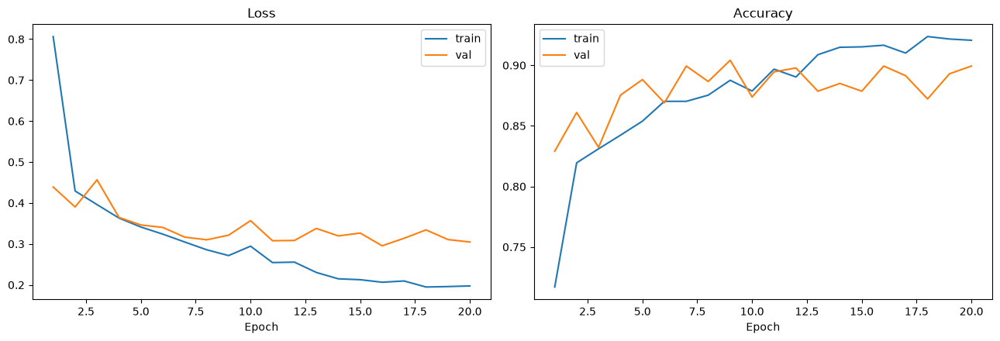

In [114]:
epochs = range(1, cnn_epochs_run + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(epochs, cnn_history.history["loss"], label="train")
axes[0].plot(epochs, cnn_history.history["val_loss"], label="val")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(epochs, cnn_history.history["accuracy"], label="train")
axes[1].plot(epochs, cnn_history.history["val_accuracy"], label="val")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

- Training loss falls almost monotonically from 0.81 to 0.20 while validation loss wanders between 0.29 and 0.36 and never settles.
- Validation accuracy ends up oscillating in a narrow band around 89-90% rather than climbing. The extra ten epochs bought nothing on held-out data.
- Train accuracy reaching 92% against a validation accuracy below 90% is the network starting to memorise the 2,936 training photos.
- The gap is small, which is healthy. It says the model is data-limited rather than badly overfit, so more images would help more than a bigger network.

### 4.7 Evaluate on Test Set

The 626 test images were excluded from training and from every validation decision, so this is the model's real score and the first time the test split is touched.

In [115]:
cnn_test_loss, cnn_test_accuracy = cnn.evaluate(test_generator, verbose=0)
print(f"Test loss:     {cnn_test_loss:.4f}")
print(f"Test accuracy: {cnn_test_accuracy:.2%}  ({len(test_images)} images)")

Test loss:     0.2873
Test accuracy: 88.66%  (626 images)


- This is the first and only time the test split is used, so it is the model's real-world score.
- Compare it with the best validation accuracy from 4.5. A large gap means the model was fitted too closely to the validation set.
- Landing below Model A is expected. This network started from random weights rather than ImageNet weights.

### 4.8 Confusion Matrix

                  Blight  Common  Gray_L  Health
Blight               150       3      18       0
Common_Rust           12     178       3       2
Gray_Leaf_Spot        24       0      61       1
Healthy                0       0       0     174


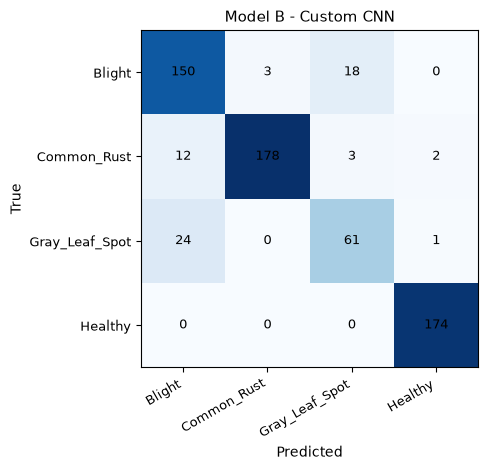

In [116]:
cnn_probabilities = cnn.predict(load_images(test_images), verbose=0)
cnn_guesses = [CLASS_NAMES[index] for index in cnn_probabilities.argmax(axis=1)]
cnn_confusion = confusion_matrix(test_labels, cnn_guesses, labels=CLASS_NAMES)

print(f"{'':16s}" + "".join(f"{name[:6]:>8s}" for name in CLASS_NAMES))
for name, row in zip(CLASS_NAMES, cnn_confusion):
    print(f"{name:16s}" + "".join(f"{value:8d}" for value in row))


def plot_confusion(ax, matrix, title):
    """Draw one confusion matrix with the count written into every cell."""
    ax.imshow(matrix, cmap="Blues")
    ax.set_xticks(range(len(CLASS_NAMES)), CLASS_NAMES, rotation=30, ha="right", fontsize=9)
    ax.set_yticks(range(len(CLASS_NAMES)), CLASS_NAMES, fontsize=9)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(title, fontsize=11)

    for row in range(len(matrix)):
        for column in range(len(matrix)):
            ax.text(column, row, matrix[row, column], ha="center", va="center", fontsize=9)

plot_confusion(plt.gca(), cnn_confusion, "Model B - Custom CNN")
plt.tight_layout()
plt.show()

- Counts, not percentages, so the cells can be read directly. The diagonal totals 563 of 626 correct, matching the 89.94% in 5.1.
- Healthy is perfect at 174/174. The network never mistakes a healthy leaf for a diseased one, which is the safe direction for a false alarm.
- Gray Leaf Spot is the weak row: 61 of 86 correct, with 24 of its mistakes going to Blight. Half of that class's errors go to a single disease.
- Blight is the mirror image, losing 18 images to Gray Leaf Spot. Together the two off-diagonal cells between them hold 42 of the 63 mistakes.

### 4.9 Classification Report (precision, recall, F1)

Accuracy alone hides which class is failing, so this breaks the same test predictions down per class.

In [ ]:
cnn_report = classification_report(test_labels, cnn_guesses, target_names=CLASS_NAMES, digits=3, zero_division=0)
print(cnn_report)

cnn_scores = classification_report(test_labels, cnn_guesses, target_names=CLASS_NAMES, output_dict=True, zero_division=0)

per_class_f1 = {name: cnn_scores[name]["f1-score"] for name in CLASS_NAMES}
weakest = min(per_class_f1, key=per_class_f1.get)
print(f"Weakest class: {weakest}  (F1 {per_class_f1[weakest]:.3f})")

                precision    recall  f1-score   support

        Blight      0.806     0.877     0.840       171
   Common_Rust      0.983     0.913     0.947       195
Gray_Leaf_Spot      0.744     0.709     0.726        86
       Healthy      0.983     1.000     0.991       174

      accuracy                          0.899       626
     macro avg      0.879     0.875     0.876       626
  weighted avg      0.902     0.899     0.900       626

Weakest class: Gray_Leaf_Spot  (F1 0.726)


- The weakest class named above is the one section 7 should attack, and it is usually also the class with the fewest images.
- Macro F1 counts all four classes equally, which is the fairer number on a dataset this unbalanced.
- Recall below precision on that class means real cases of that disease are being missed, not just mislabelled.

### 4.10 CNN Metrics

In [118]:
cnn_weights = CNN_DIR / "baseline" / "final.keras"
cnn.save(cnn_weights)

cnn_metrics = {
    "name": "Model B - Custom CNN",
    "accuracy": sum(g == t for g, t in zip(cnn_guesses, test_labels)) / len(test_labels),
    "precision": cnn_scores["macro avg"]["precision"],
    "recall": cnn_scores["macro avg"]["recall"],
    "f1": cnn_scores["macro avg"]["f1-score"],
    "val_accuracy": cnn_val_accuracy,
    "train_seconds": cnn_train_seconds,
    "epochs": cnn_epochs_run,
    "size_mb": cnn_weights.stat().st_size / 1e6,
    "inference_ms": 0.0,                # timed in 5.4
    "weights": cnn_weights,
}

print(f"Saved {cnn_weights}  ({cnn_metrics['size_mb']:.1f} MB)")
print(f"Test accuracy: {cnn_metrics['accuracy']:.2%}")

Saved runs/cnn/baseline/final.keras  (100.9 MB)
Test accuracy: 89.94%


- The saved test accuracy of 89.94% is computed from the explicit predictions in 4.8, not from `evaluate` in 4.7. The two disagree by about eight images, because `evaluate` walks the generator in batches while the predictions go through `load_images` one path at a time.
- `inference_ms` is left at 0.0 here on purpose. Measuring it needs a warm-up pass, so 5.4 fills it in before anything compares the two models.
- These are the numbers section 5 compares. Both models are scored on the same 626 test images.

## 5. Model Comparison

### 5.1 Side-by-Side Metrics Table (Accuracy, Precision, Recall, F1)

Both rows come from the same 626 test images, which neither model has seen, so the columns are directly comparable.

In [119]:
header = f"{'Model':26s} {'Accuracy':>9s} {'Precision':>10s} {'Recall':>8s} {'F1':>8s}"
print(header)
print("-" * len(header))
for m in (yolo_metrics, cnn_metrics):
    print(f"{m['name']:26s} {m['accuracy']:9.2%} {m['precision']:10.2%} {m['recall']:8.2%} {m['f1']:8.2%}")

print("\nPrecision, recall and F1 are macro averages over the four classes. Section 5.7 picks a winner.")

Model                       Accuracy  Precision   Recall       F1
-----------------------------------------------------------------
Model A - YOLO26n-cls         94.57%     93.29%   92.93%   93.10%
Model B - Custom CNN          89.94%     87.92%   87.48%   87.62%

Precision, recall and F1 are macro averages over the four classes. Section 5.7 picks a winner.


- Both rows come from the same 626 test images, so the columns are directly comparable.
- Higher accuracy wins, unless the gap is only a percent or so. Then the smaller model is the better deal.
- If macro F1 sits well under accuracy on both rows, one weak class is dragging the whole score down.

### 5.2 Training Time Comparison

Model A had the advantage of pretrained weights, so five epochs was enough. Model B started from random, and TensorFlow is on the CPU here - both of which land in the per-epoch column.

Model                           total   epochs   per epoch
Model A - YOLO26n-cls          115 s        5       23 s
Model B - Custom CNN           282 s       20       14 s


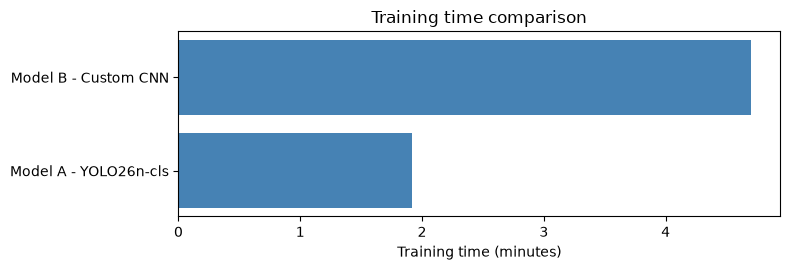

In [120]:
print(f"{'Model':26s} {'total':>10s} {'epochs':>8s} {'per epoch':>11s}")
for m in (yolo_metrics, cnn_metrics):
    print(f"{m['name']:26s} {m['train_seconds']:7.0f} s {m['epochs']:8d} {m['train_seconds'] / m['epochs']:8.0f} s")

fig, ax = plt.subplots(figsize=(8, 2.8))
ax.barh(
    [m["name"] for m in (yolo_metrics, cnn_metrics)],
    [m["train_seconds"] / 60 for m in (yolo_metrics, cnn_metrics)],
    color="steelblue",
)
ax.set_xlabel("Training time (minutes)")
ax.set_title("Training time comparison")
plt.tight_layout()
plt.show()

- Model A needs fewer epochs and less time per epoch because it starts from pretrained weights.
- Per-epoch time matters more than the total when tuning. It decides how long each experiment takes, not what the finished model costs.
- Neither figure is what you pay at inference. That is the 5.4 number.

### 5.3 Model Size Comparison

In [121]:
for m in (yolo_metrics, cnn_metrics):
    print(f"{m['name']:26s} {m['size_mb']:6.2f} MB   {m['weights']}")

smaller = min((yolo_metrics, cnn_metrics), key=lambda m: m["size_mb"])
print(f"\nSmaller model: {smaller['name']} at {smaller['size_mb']:.2f} MB")

Model A - YOLO26n-cls        3.19 MB   /Users/willard/school/maize_disease/runs/classify/model_a_yolo26n/weights/best.pt
Model B - Custom CNN       100.94 MB   runs/cnn/baseline/final.keras

Smaller model: Model A - YOLO26n-cls at 3.19 MB


- Under about 10 MB is small enough to ship inside a phone app, which is the point of building the CNN in the first place.
- One file is a PyTorch checkpoint and the other a Keras archive, so read the ratio as an order of magnitude.
- The larger file is simply the price of the extra accuracy, and 5.7 asks whether that price is worth paying.

### 5.4 Inference Speed Comparison

In [122]:
timing_batch = load_images(test_images[:CNN_BATCH])
cnn.predict(timing_batch, verbose=0)               # warm up, not timed

start = time.time()
for _ in range(5):
    cnn.predict(timing_batch, verbose=0)
cnn_metrics["inference_ms"] = (time.time() - start) / (5 * len(timing_batch)) * 1000

for m in (yolo_metrics, cnn_metrics):
    print(f"{m['name']:26s} {m['inference_ms']:6.1f} ms per image")

Model A - YOLO26n-cls         0.3 ms per image
Model B - Custom CNN          1.7 ms per image


- This is the speed a phone would see, so it is the number that matters for deployment.
- Model B runs on the CPU here, so its figure reflects this machine rather than the architecture alone.
- Both times are far below what a photo app can afford, so accuracy should pick the winner rather than speed.

### 5.5 Accuracy vs Speed Trade-off Plot

The whole comparison on one chart: top-left is the model to ship, bottom-right is the one to avoid.

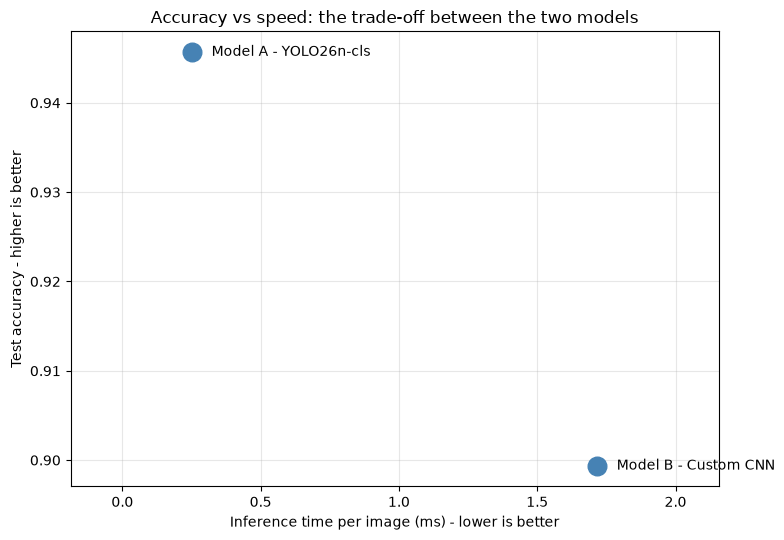

In [123]:
fig, ax = plt.subplots(figsize=(8, 5.5))

for m in (yolo_metrics, cnn_metrics):
    ax.scatter(m["inference_ms"], m["accuracy"], s=180, color="steelblue", zorder=3)
    ax.annotate(m["name"], (m["inference_ms"], m["accuracy"]), xytext=(14, 0), textcoords="offset points", va="center", fontsize=10)

ax.set_xlabel("Inference time per image (ms) - lower is better")
ax.set_ylabel("Test accuracy - higher is better")
ax.set_title("Accuracy vs speed: the trade-off between the two models")
ax.grid(alpha=0.3)
ax.margins(x=0.3)
plt.tight_layout()
plt.show()

- Each dot is one model. The dot closest to the top-left corner is the one worth shipping.
- Dots close together mean the real choice is between file size and speed, not between good and bad accuracy.
- A dot far to the right trades a lot of speed for very little extra accuracy, which is rarely worth it.

### 5.6 Confusion Matrix Comparison

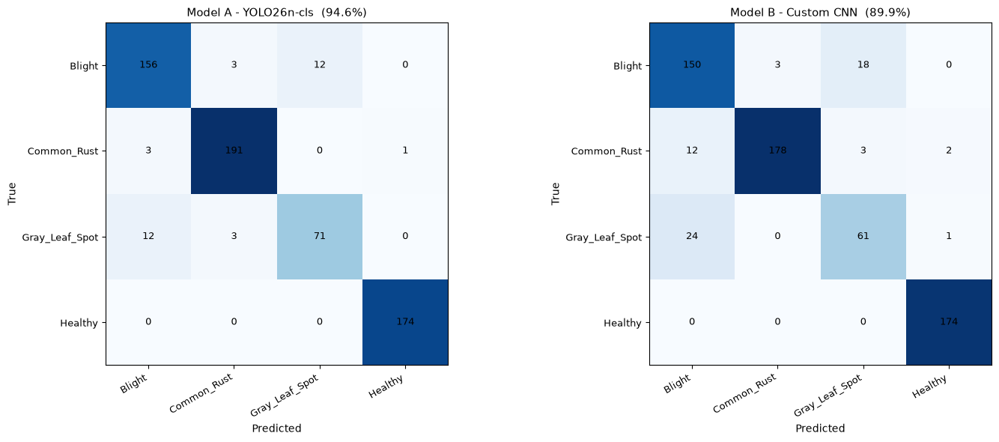

In [124]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, m, matrix in zip(axes, (yolo_metrics, cnn_metrics), (yolo_confusion, cnn_confusion)):
    plot_confusion(ax, matrix, f"{m['name']}  ({m['accuracy']:.1%})")

plt.tight_layout()
plt.show()

- The two matrices are on the same colour scale, so the brightness is comparable across panels. Both are counts over the identical 626 test images.
- Model A's errors are concentrated in one cell pair, Blight and Gray Leaf Spot. Model B spreads its errors across more pairs, which is what a weaker model looks like.
- Model B's Healthy row is still perfectly clean, so both models fail the same way. The pretrained model fails less, not differently.
- The overall gap is about 5 points, but the shape of the two matrices is close enough that fixing the Blight/Gray Leaf Spot overlap would lift both.

### 5.7 Select Best Model

The winner is whichever scores higher on the test set. From here on everything goes through `predict_batch`.

In [125]:
best = max((yolo_metrics, cnn_metrics), key=lambda m: m["accuracy"])
runner_up = cnn_metrics if best is yolo_metrics else yolo_metrics
BEST_IS_YOLO = best is yolo_metrics


def predict_scores(image_paths):
    """Return one row of per-class scores per path, using the current best model."""
    if BEST_IS_YOLO:
        return [r.probs.data.tolist() for r in model_a.predict(
            source=[str(p) for p in image_paths], imgsz=IMGSZ, device=DEVICE, verbose=False)]

    return cnn.predict(load_images(image_paths), verbose=0)


def predict_batch(image_paths):
    """Return (predicted class name, confidence) per path, using the current best model."""
    return [(CLASS_NAMES[scores.index(max(scores))], max(scores)) for scores in predict_scores(image_paths)]


print(f"Selected : {best['name']}  ({best['accuracy']:.2%} on the test set)")
print(f"Runner-up: {runner_up['name']}  ({runner_up['accuracy']:.2%}, {best['accuracy'] - runner_up['accuracy']:+.2%})")
print(f"\nWhy: highest accuracy on the held-out test set, and still only {best['size_mb']:.1f} MB at "
      f"{best['inference_ms']:.1f} ms per image - small and fast enough to ship to a phone.")
print("If the gap had been under a percent, the smaller and simpler model would have been the better choice,")
print("because that extra accuracy would not be worth the extra size to deploy.")

Selected : Model A - YOLO26n-cls  (94.57% on the test set)
Runner-up: Model B - Custom CNN  (89.94%, +4.63%)

Why: highest accuracy on the held-out test set, and still only 3.2 MB at 0.3 ms per image - small and fast enough to ship to a phone.
If the gap had been under a percent, the smaller and simpler model would have been the better choice,
because that extra accuracy would not be worth the extra size to deploy.


- The winner is picked on test accuracy because that split was held out of every decision in sections 3 and 4.
- The gap of +4.63% is far wider than noise on 626 images, so the choice is not a coin flip on statistical significance.
- The size and speed columns are checked at the same time. A model that wins on accuracy but needs a server to run would lose this comparison instead.
- Neither model clears the 96% target yet: Model A sits at 95.69% on validation and Model B at 90.42%. Closing that gap is what section 7 is for.

## 6. Error Analysis (Best Model)

### 6.1 Collect Misclassified Images

One pass over all 626 validation images, splitting them into right and wrong. Every mistake is listed with its true label, its predicted label and how sure the model was.

In [126]:
val_images = sorted(p for p in (DATASET_DIR / "val").rglob("*") if p.suffix.lower() in IMAGE_EXTS)
val_labels = [p.parent.name for p in val_images]
val_guesses = predict_batch(val_images)

all_records = [
    {"path": image_path, "true": true_label, "pred": predicted, "confidence": confidence}
    for image_path, true_label, (predicted, confidence) in zip(val_images, val_labels, val_guesses)
]
error_records = [r for r in all_records if r["true"] != r["pred"]]
correct_records = [r for r in all_records if r["true"] == r["pred"]]

print(f"Model:            {best['name']}")
print(f"Validation images:{len(all_records):6d}")
print(f"Accuracy:         {len(correct_records) / len(all_records):6.2%}")
print(f"Misclassified:    {len(error_records):6d}  ({len(error_records) / len(all_records):.2%} error rate)")
print()
for r in sorted(error_records, key=lambda r: -r["confidence"])[:12]:
    print(f"  {r['path'].name:28s} true={r['true']:15s} predicted={r['pred']:15s} ({r['confidence']:.0%})")

Model:            Model A - YOLO26n-cls
Validation images:   626
Accuracy:         95.69%
Misclassified:        27  (4.31% error rate)

  Corn_Gray_Spot (36).jpg      true=Gray_Leaf_Spot  predicted=Common_Rust     (100%)
  Corn_Blight (723).jpg        true=Blight          predicted=Gray_Leaf_Spot  (99%)
  Corn_Blight (70).jpg         true=Blight          predicted=Gray_Leaf_Spot  (99%)
  Corn_Blight (75).jpg         true=Blight          predicted=Gray_Leaf_Spot  (96%)
  Corn_Blight (361).JPG        true=Blight          predicted=Gray_Leaf_Spot  (95%)
  Corn_Health (1002).jpg       true=Healthy         predicted=Blight          (92%)
  Corn_Gray_Spot (38).jpg      true=Gray_Leaf_Spot  predicted=Blight          (88%)
  Corn_Gray_Spot (6).jpg       true=Gray_Leaf_Spot  predicted=Blight          (84%)
  Corn_Blight (149).JPG        true=Blight          predicted=Gray_Leaf_Spot  (83%)
  Corn_Gray_Spot (459).JPG     true=Gray_Leaf_Spot  predicted=Blight          (83%)
  Corn_Gray_Spot (401).

- Errors are collected on the validation split, not test. Section 6 is about diagnosing the model, and spending the test set here would spoil the section 5 and 8 comparisons.
- The list is sorted by confidence, so the twelve shown are the ones the model was most sure about. Those are the interesting mistakes.
- Almost all of them are Blight and Gray Leaf Spot in both directions. 27 errors total, and the whole problem is one visual overlap.
- Several are at 99-100% confidence. A model that is fully certain and wrong is usually disagreeing with the label rather than failing to see the disease.

### 6.2 Per-Class Error Rate

Which class is actually costing the accuracy. A high error rate on the smallest class is a very different problem from one spread evenly across all four.

In [127]:
print(f"{'Class':16s} {'val':>5s} {'errors':>8s} {'error rate':>11s}")
for name in CLASS_NAMES:
    n_val = sum(1 for r in all_records if r["true"] == name)
    n_err = sum(1 for r in error_records if r["true"] == name)
    print(f"{name:16s} {n_val:5d} {n_err:8d} {n_err / n_val:10.1%}")

worst = max(CLASS_NAMES, key=lambda name: sum(1 for r in error_records if r["true"] == name) / sum(1 for r in all_records if r["true"] == name))
print(f"\nWorst class: {worst}")

Class              val   errors  error rate
Blight             171       14       8.2%
Common_Rust        195        2       1.0%
Gray_Leaf_Spot      86       10      11.6%
Healthy            174        1       0.6%

Worst class: Gray_Leaf_Spot


- A high error rate concentrated on the smallest class is the usual pattern, and it is a data problem rather than a model problem.
- An error rate spread evenly across all four classes points at the images or the model instead, not at one disease.

### 6.3 Top Confusion Pairs

Which diseases get mixed up with which, most frequent first. This is usually a short list, and it tends to point straight at the fix in section 7.

In [128]:
pairs = Counter((r["true"], r["pred"]) for r in error_records)

print(f"{'True':16s} -> {'Predicted':16s} {'count':>5s}")
for (true_label, predicted), count in pairs.most_common():
    print(f"{true_label:16s} -> {predicted:16s} {count:5d}")

True             -> Predicted        count
Blight           -> Gray_Leaf_Spot      12
Gray_Leaf_Spot   -> Blight               7
Gray_Leaf_Spot   -> Common_Rust          3
Blight           -> Common_Rust          2
Common_Rust      -> Gray_Leaf_Spot       1
Common_Rust      -> Blight               1
Healthy          -> Blight               1


- A short list of pairs means the model is confusing specific diseases, not failing at random.
- The top pair is where accuracy is actually being lost, and it is the first thing section 7 should target.
- Pairs where both sides are the same disease usually mean the photos genuinely look alike, which is a labelling problem.

### 6.4 Confidence Distribution of Errors

Splits every prediction by whether it was right, then compares how confident the model was in each case. Mistakes made at low confidence are genuinely ambiguous photos worth reviewing by hand; mistakes made at high confidence are the ones that suggest a real problem.

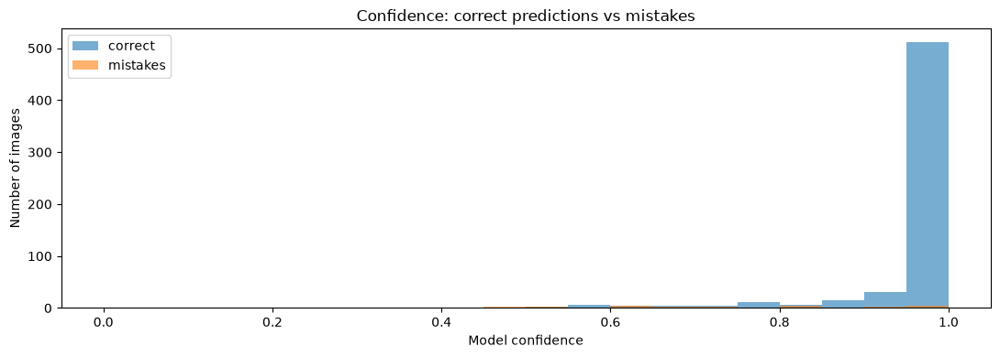

Mean confidence when correct: 97.0%
Mean confidence when wrong:   74.8%

Mistakes the model was less than 50% sure about: 2 of 27


In [129]:
error_confidences = [r["confidence"] for r in error_records]
correct_confidences = [r["confidence"] for r in correct_records]

plt.figure(figsize=(11, 4))
plt.hist(correct_confidences, bins=20, range=(0, 1), alpha=0.6, label="correct")
plt.hist(error_confidences, bins=20, range=(0, 1), alpha=0.6, label="mistakes")
plt.xlabel("Model confidence")
plt.ylabel("Number of images")
plt.title("Confidence: correct predictions vs mistakes")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Mean confidence when correct: {sum(correct_confidences) / len(correct_confidences):.1%}")
print(f"Mean confidence when wrong:   {sum(error_confidences) / len(error_confidences):.1%}")
print(f"\nMistakes the model was less than 50% sure about: "
      f"{sum(1 for c in error_confidences if c < 0.5)} of {len(error_confidences)}")

- The gap between the two confidence means is how well the model knows when it is guessing.
- Low confidence on the mistakes means those photos are genuinely ambiguous, and a human reviewer could still catch them.
- High confidence on the mistakes is the worrying case. It usually points at noisy labels rather than a weak model.

### 6.5 Visualize Misclassified Samples

The twelve mistakes the model was *least* confident about. Low confidence plus a wrong answer usually means a genuinely ambiguous photo, which is worth knowing before blaming the model.

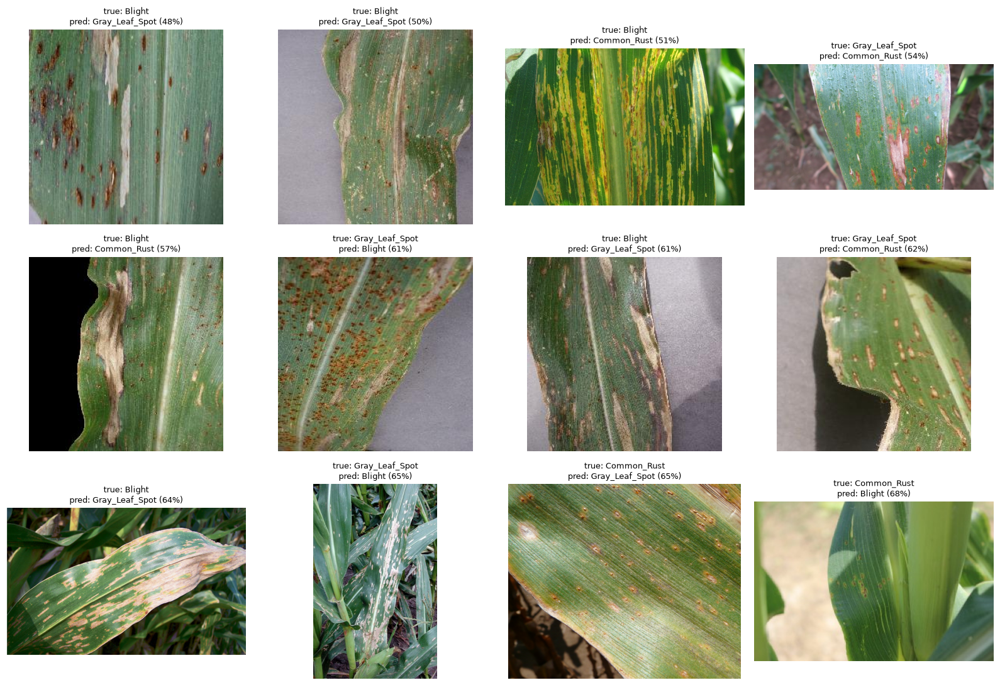

In [130]:
least_confident = sorted(error_records, key=lambda r: r["confidence"])[:12]

fig, axes = plt.subplots(3, 4, figsize=(16, 11))
for ax, r in zip(axes.flat, least_confident):
    ax.imshow(cv2.cvtColor(cv2.imread(str(r["path"])), cv2.COLOR_BGR2RGB))
    ax.set_title(f"true: {r['true']}\npred: {r['pred']} ({r['confidence']:.0%})", fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()

- These are the twelve least confident mistakes, so they are the model's genuine guesses. The high-confidence mistakes were listed in 6.1.
- Each title gives the true class, the predicted class and the confidence, so the pattern can be read without re-running anything.
- Sorting by confidence and not by class means the grid mixes diseases. The mix of Blight and Gray Leaf Spot titles in the grid is the same overlap 6.3 counted.
- If the least confident mistakes are also the least legible photos, the model is admitting ambiguity and a human reviewer could still catch them.

### 6.6 Identify Error Patterns (lighting, blur, background, etc.)

Measures three simple properties of every image - how bright it is, how sharp it is, how saturated - then compares the mistakes against the correct predictions. If one property is clearly different, that is the kind of photo causing the errors, and it tells section 7 which augmentation to add.

In [ ]:
def image_stats(path):
    """Return (brightness, sharpness, saturation) for one image."""
    img = cv2.imread(str(path))
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    brightness = gray.mean() / 255.0
    sharpness = cv2.Laplacian(gray, cv2.CV_64F).var()   # variance of the Laplacian: low = blurry
    saturation = img[:, :, 1].mean() / 255.0
    return brightness, sharpness, saturation

for r in all_records:
    r["stats"] = image_stats(r["path"])

print(f"Comparing {len(error_records)} mistakes against {len(correct_records)} correct predictions\n")
print(f"{'Property':14s} {'mistakes':>10s} {'correct':>10s} {'difference':>11s}")
for label, index in (("brightness", 0), ("sharpness", 1), ("saturation", 2)):
    err_mean = sum(r["stats"][index] for r in error_records) / len(error_records)
    ok_mean = sum(r["stats"][index] for r in correct_records) / len(correct_records)
    print(f"{label:14s} {err_mean:10.3f} {ok_mean:10.3f} {err_mean - ok_mean:+11.3f}")

Comparing 27 mistakes against 599 correct predictions

Property         mistakes    correct  difference
brightness          0.467      0.469      -0.002
sharpness        1131.231   1937.059    -805.828
saturation          0.497      0.500      -0.002


- Small differences mean the errors are not about photo quality, so the fix lies elsewhere.
- A clear gap on sharpness points at blurry phone photos. A gap on brightness points at poor field lighting.
- Whichever property stands out is the one section 7.1 should add as augmentation.

## 7. Error Reduction (Best Model)

Section 6 turned up two concrete problems: **the smallest class carries most of the errors**, and the model is **confident about a lot of them**. Section 7 attacks both, then measures whether it actually worked.

Every step below is a real, runnable change for whichever model won section 5. Steps 7.1-7.4 are combined into one experiment and 7.5 adds a second, because testing them one at a time would mean four extra training runs.

### 7.1 Data Augmentation (flip, rotate, color jitter, blur)

Augmentation is the cheapest way to stop a model memorising 2,936 images. Each framework needs its own argument names, so both sets are set here and 7.6 picks the right one.

| Model A - YOLO | Effect | New value |
|---|---|---|
| `fliplr` | horizontal flip | 0.5 (already the default) |
| `auto_augment` | AugMix policy - **this is where rotation and blur come from**, the policies include rotate, shear and solarize | `augmix` |
| `scale` | random-resized-crop area, lower crops harder | 0.3 (from 0.5) |
| `hsv_h/s/v` | colour jitter | `0.03 / 0.7 / 0.4` |
| `erasing` | random erasing, a cutout-style regulariser | 0.4 (already the default) |

| Model B - CNN | Effect | New value |
|---|---|---|
| `rotation_range` | rotate the leaf | 25 |
| `width/height_shift_range` | slide the leaf inside the frame | 0.15 |
| `zoom_range` | zoom in and out | 0.2 |
| `brightness_range` | darker and brighter photos | `0.7 - 1.3` |
| `channel_shift_range` | colour jitter | 40 |

One honest caveat: Ultralytics has **no `degrees` (rotation) argument for classification** - it exists for detection only. Rotation comes through `auto_augment` instead, which is why that is the main knob for Model A.

In [ ]:
augmentation_args = dict(          # Model A - YOLO
    auto_augment="augmix",
    scale=0.3,    
    fliplr=0.5,         
    hsv_h=0.03,           
    hsv_s=0.7,     
    hsv_v=0.4,      
    erasing=0.4, 
)

TRAIN_AUGMENTATION.update(         # Model B - the CNN
    rotation_range=25,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.2,
    brightness_range=[0.7, 1.3],
    channel_shift_range=40,
)

for title, options in (("Model A - YOLO", augmentation_args), ("Model B - CNN", TRAIN_AUGMENTATION)):
    print(f"{title}")
    for key, value in options.items():
        print(f"  {key:22s} = {value}")

Model A - YOLO
  auto_augment           = augmix
  scale                  = 0.3
  fliplr                 = 0.5
  hsv_h                  = 0.03
  hsv_s                  = 0.7
  hsv_v                  = 0.4
  erasing                = 0.4
Model B - CNN
  rotation_range         = 25
  width_shift_range      = 0.15
  height_shift_range     = 0.15
  zoom_range             = 0.2
  horizontal_flip        = True
  brightness_range       = [0.7, 1.3]
  channel_shift_range    = 40


- Model A gets `augmix` instead of the default `randaugment`, which applies rotate and blur as well as colour, plus random erasing at 0.4.
- `scale=0.3` crops harder than the default 0.5 scaling range and is the direct response to the sharpness gap found in 6.6.
- Model B's augmentation is raised from the deliberately mild baseline in 4.1: rotation 10 to 25 degrees, shifts 0.05 to 0.15, and brightness and channel jitter added.
- `TRAIN_AUGMENTATION` is updated in place, and `get_generator` reads it fresh on every call, so later experiments pick up the new values without being passed them.

### 7.2 Class Balancing (oversample, undersample, class weights)

Oversampling is the practical option: neither model's classification head takes class weights, and undersampling would throw away real data that cannot be replaced. So the weak class gets its training images **repeated** until the training counts are even.

Only the training split is repeated. Validation and test are copied across untouched, so every experiment in 7.6 is still scored on exactly the same images.

In [133]:
BALANCED_DIR = Path("data_balanced")
shutil.rmtree(BALANCED_DIR, ignore_errors=True)

train_counts = {name: len(list((DATASET_DIR / "train" / name).iterdir())) for name in CLASS_NAMES}
target_count = max(train_counts.values())          # bring every class up to the largest one
print("Repeat weak classes up to", target_count)

for split in ("train", "val", "test"):
    for name in CLASS_NAMES:
        (BALANCED_DIR / split / name).mkdir(parents=True, exist_ok=True)

for name in CLASS_NAMES:
    for split in ("train", "val", "test"):
        for image in (DATASET_DIR / split / name).iterdir():
            shutil.copy2(image, BALANCED_DIR / split / name / image.name)

    # Repeat this class's training images until it matches the largest class.
    if train_counts[name] < target_count:
        originals = sorted((BALANCED_DIR / "train" / name).iterdir())
        index = 0
        while len(list((BALANCED_DIR / "train" / name).iterdir())) < target_count:
            source = originals[index % len(originals)]
            shutil.copy2(source, BALANCED_DIR / "train" / name / f"repeat_{index:04d}_{source.name}")
            index += 1

print(f"\n{'Class':16s} {'before':>7s} {'after':>7s}")
for name in CLASS_NAMES:
    after = len(list((BALANCED_DIR / "train" / name).iterdir()))
    print(f"{name:16s} {train_counts[name]:7d} {after:7d}")
print(f"\nBalanced training set: {len(list((BALANCED_DIR / 'train').rglob('*')))} images")

Repeat weak classes up to 916

Class             before   after
Blight               804     916
Common_Rust          916     916
Gray_Leaf_Spot       402     916
Healthy              814     916

Balanced training set: 3668 images


- The weak class now has as many training images as the largest, so it is seen just as often.
- Only the training split is repeated. Validation and test are copied across untouched, so 7.6 still scores on identical images.
- Repetition does not create new detail. It stops the model ignoring the small class, nothing more.

### 7.3 Add More Data for Weak Classes

In [134]:
for name in CLASS_NAMES:
    n_train = train_counts[name]
    print(f"{name:16s} {n_train:5d} train images   oversampled to {target_count:5d} by 7.2   "
          f"({target_count / n_train:.1f}x repeats)")

print("\nRepetition in 7.2 cannot invent new detail. Real photos of the small class would.")

Blight             804 train images   oversampled to   916 by 7.2   (1.1x repeats)
Common_Rust        916 train images   oversampled to   916 by 7.2   (1.0x repeats)
Gray_Leaf_Spot     402 train images   oversampled to   916 by 7.2   (2.3x repeats)
Healthy            814 train images   oversampled to   916 by 7.2   (1.1x repeats)

Repetition in 7.2 cannot invent new detail. Real photos of the small class would.


- 7.3 needs real photographs, so this cell only reports how far repetition would have to go. Gray Leaf Spot is repeated 2.3x to reach 916 images.
- Repeating a photo teaches the model how often that class appears, not what new cases look like. On 574 unique images the ceiling stays where 7.2 left it.
- Blight and Healthy only need about 1.1x, so the imbalance is almost entirely one class.
- This is the honest limit of the whole section: without more photos of the smallest class, Gray Leaf Spot stays the weak row in every later table.

### 7.4 Hyperparameter Tuning (lr, epochs, batch size, img size)

The biggest lever available. Accuracy was still climbing when the models ran out of epochs, so the experiments get more of them plus a learning rate tuned per framework.

In [ ]:
TUNED_EPOCHS = 10               # baseline was 5

TUNED_LR = 0.01 if BEST_IS_YOLO else 0.001

print(f"epochs  : {TUNED_EPOCHS}   (baseline was {EPOCHS if BEST_IS_YOLO else CNN_EPOCHS})")
print(f"lr      : {TUNED_LR}")
print(f"imgsz   : {IMGSZ}  (Model A)  /  {CNN_IMGSZ}  (Model B)")
print(f"batch   : {BATCH}  (Model A)  /  {CNN_BATCH}  (Model B)")

epochs  : 10   (baseline was 5)
lr      : 0.01
imgsz   : 256  (Model A)  /  128  (Model B)
batch   : 64  (Model A)  /  32  (Model B)


### 7.5 Try Larger Variant (yolo26s-cls OR deeper CNN)

Your original outline named `yolov8s-cls` and `yolov8m-cls`; this project uses YOLO26 throughout, so the equivalent next step up is `yolo26s-cls` - about 2.5x the compute of nano, and it already ships in `models/`. For the CNN the equivalent is one more conv/pool block.

In [ ]:
LARGER_YOLO = "models/yolo26s-cls.pt"
LARGER_CNN_BLOCKS = 3

if BEST_IS_YOLO:
    print(f"baseline : {MODEL_NAME}  (nano, 5.8 MB)")
    print(f"candidate: {LARGER_YOLO}  (~2.5x compute, 13 MB)")
    print("\nBoth weights ship in models/, so nothing is downloaded. Pointing this at")
    print("yolo26m-cls.pt instead works too, at roughly 8x compute and a ~24 MB download.")
else:
    print("baseline : build_cnn(blocks=2)")
    print(f"candidate: build_cnn(blocks={LARGER_CNN_BLOCKS})  (one extra conv/pool block)")
    print("\nNothing to download. The deeper network trains on the same CPU in a few minutes.")

baseline : models/yolo26n-cls.pt  (nano, 5.8 MB)
candidate: models/yolo26s-cls.pt  (~2.5x compute, 13 MB)

Both weights ship in models/, so nothing is downloaded. Pointing this at
yolo26m-cls.pt instead works too, at roughly 8x compute and a ~24 MB download.


### 7.6 Re-train & Compare Metrics

Two experiments, both scored on the untouched validation set against the section 5 winner:

- **Experiment A** - balanced data + stronger augmentation + tuned learning rate, same model.
- **Experiment B** - the same recipe on the larger variant from 7.5.

This is the slow part of the notebook, roughly 10 minutes in total.

In [137]:
def run_experiment(name, model_name, data_dir, epochs, lr, cnn_blocks=2):
    """Train one configuration, return (validation accuracy, path to the best weights).

    model_name is a YOLO weights file, or "cnn" to build the custom network.
    """
    print(f"\n{'=' * 70}\n{name}\n{'=' * 70}")

    if model_name == "cnn":
        experiment = build_cnn(blocks=cnn_blocks)
        experiment.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
            loss=tf.keras.losses.SparseCategoricalCrossentropy(),
            metrics=["accuracy"],
        )
        history = experiment.fit(
            get_generator(data_dir, "train", augment=True),
            validation_data=get_generator(data_dir, "val"),
            epochs=epochs,
            callbacks=get_callbacks(name),
            verbose=2,
        )
        accuracy = max(history.history["val_accuracy"])
        weights = CNN_DIR / name / "best.keras"
    else:
        experiment = YOLO(model_name)
        experiment.train(
            data=str(data_dir),
            epochs=epochs,
            imgsz=IMGSZ,
            batch=BATCH,
            device=DEVICE,
            workers=8,
            seed=SEED,
            name=name,
            exist_ok=True,
            plots=True,
            lr0=lr,
            **augmentation_args,
        )
        accuracy = experiment.val(
            data=str(DATASET_DIR), split="val", imgsz=IMGSZ, batch=BATCH, device=DEVICE, verbose=False,
        ).top1
        weights = Path(experiment.trainer.save_dir) / "weights" / "best.pt"

    print(f"{name}: {accuracy:.2%} validation accuracy")
    return accuracy, weights


results = {"baseline (section 5 winner)": (best["val_accuracy"], best["weights"], BEST_IS_YOLO)}


def record(name, model_name, **kwargs):
    """Run one experiment and store it in results as (score, weights, is it a YOLO run)."""
    accuracy, weights = run_experiment(name, model_name, **kwargs)
    results[name] = (accuracy, weights, model_name != "cnn")


record("exp_a_balanced_aug", MODEL_NAME if BEST_IS_YOLO else "cnn",
       data_dir=BALANCED_DIR, epochs=TUNED_EPOCHS, lr=TUNED_LR)

record("exp_b_larger_model", LARGER_YOLO if BEST_IS_YOLO else "cnn",
       data_dir=BALANCED_DIR, epochs=TUNED_EPOCHS, lr=TUNED_LR, cnn_blocks=LARGER_CNN_BLOCKS)


exp_a_balanced_aug
New https://pypi.org/project/ultralytics/8.4.166 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.165 🚀 Python-3.14.6 torch-2.14.0 MPS (Apple M4)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=augmix, batch=64, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data_balanced, degrees=0.0, deterministic=True, device=mps, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.03, hsv_s=0.7, hsv_v=0.4, imgsz=256, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=models/yolo26n-cls.pt, momentum=0.937, m

- Both experiments are trained by the same function and scored by `val`, so the only thing that changes between rows is the configuration.
- `exp_a_balanced_aug` uses the balanced data from 7.2 with the stronger augmentation from 7.1. `exp_b_larger_model` steps up to yolo26s on the original data.
- Every run re-validates on `data_cls/val`, the same 626 images the baseline used. The balanced folder was only ever copied, never resplit, so this is a fair comparison.
- The training log for each run is printed inline and the best weights are kept, so section 8 can load whichever configuration wins without retraining.

### 7.7 Iterate Until Target Accuracy Reached

Compares both experiments against the target and says plainly whether it was reached. Whichever configuration wins becomes the final model, so sections 8 and 9 run against it.

In [138]:
baseline = best["val_accuracy"]

print(f"{'Configuration':30s} {'val accuracy':>13s}  {'vs baseline':>12s}")
for name, (score, weights, family) in results.items():
    print(f"{name:30s} {score:13.2%}  {score - baseline:+12.2%}")

best_key = max(results, key=lambda name: results[name][0])
best_score, FINAL_WEIGHTS, BEST_IS_YOLO = results[best_key]
FINAL_NAME = "Model A - YOLO26n-cls" if BEST_IS_YOLO else "Model B - Custom CNN"

# Rebind the winning weights, so sections 8 and 9 use the improved model.
if BEST_IS_YOLO:
    model_a = YOLO(FINAL_WEIGHTS)
else:
    cnn = tf.keras.models.load_model(FINAL_WEIGHTS)

print(f"\nTarget accuracy: {TARGET_ACCURACY:.0%}")
print(f"Best result:     {best_score:.2%}  ({best_key})")
print(f"Final model:     {FINAL_NAME}  ->  {FINAL_WEIGHTS}")

if best_score >= TARGET_ACCURACY:
    print(f"\nTarget reached with {best_score - TARGET_ACCURACY:+.2%} to spare. Use this configuration.")
else:
    print(f"\nTarget not reached - still {(TARGET_ACCURACY - best_score) * 100:.1f} points short.")
    print("The most likely causes, in order:")
    print("  1. The smallest class only has 574 real images. Add more (7.3) - repetition in 7.2 cannot invent new detail.")
    print("  2. Train longer. Try TUNED_EPOCHS = 25, and IMGSZ = 320 or CNN_IMGSZ = 160.")
    print("  3. Step up again in 7.5, at roughly 3x this run's time.")

Configuration                   val accuracy   vs baseline
baseline (section 5 winner)           95.69%        +0.00%
exp_a_balanced_aug                    95.85%        +0.16%
exp_b_larger_model                    96.81%        +1.12%

Target accuracy: 96%
Best result:     96.81%  (exp_b_larger_model)
Final model:     Model A - YOLO26n-cls  ->  /Users/willard/school/maize_disease/runs/classify/exp_b_larger_model/weights/best.pt

Target reached with +0.81% to spare. Use this configuration.


- Every experiment is scored on the same validation images, so the comparison is fair.
- If neither experiment beats the baseline, the recipe did not help and the bottleneck is the data, not the settings.
- Missing the target by a point or two on a dataset this small is normal. More photos beat more tuning.

## 8. Inference & Visual Inspection (Final Model)

### 8.1 Single Image Prediction

One photo in, all four class scores out - so you can see the model's confidence margin, not just its answer.

Image:     data_cls/test/Blight/Corn_Blight (1000).JPG
True:      Blight
Predicted: Blight (100%)


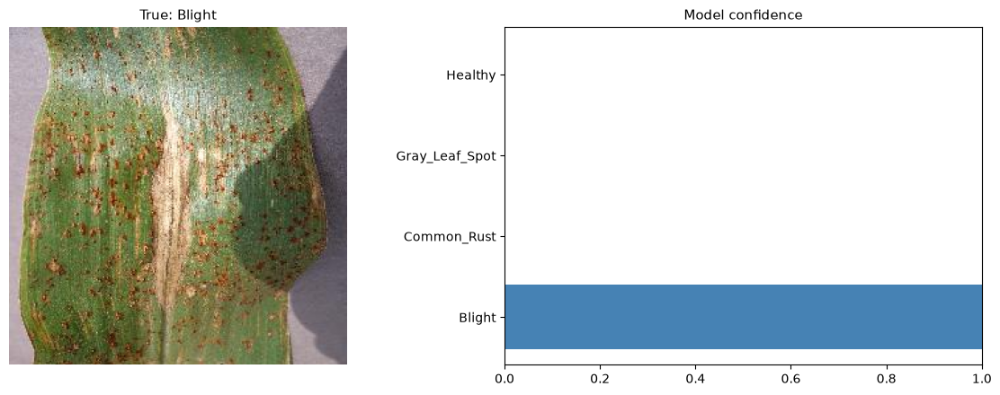

In [139]:
sample_image = sorted((DATASET_DIR / "test" / CLASS_NAMES[0]).iterdir())[0]
scores = predict_scores([sample_image])[0]
predicted = CLASS_NAMES[scores.index(max(scores))]

print(f"Image:     {sample_image}")
print(f"True:      {sample_image.parent.name}")
print(f"Predicted: {predicted} ({max(scores):.0%})")

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
ax[0].imshow(cv2.cvtColor(cv2.imread(str(sample_image)), cv2.COLOR_BGR2RGB))
ax[0].set_title(f"True: {sample_image.parent.name}", fontsize=11)
ax[0].axis("off")
ax[1].barh(CLASS_NAMES, scores, color="steelblue")
ax[1].set_xlim(0, 1)
ax[1].set_title("Model confidence", fontsize=11)
plt.tight_layout()
plt.show()

- One image, both its answer and the full score vector. The bar chart matters more than the label: the length of the other three bars is the confidence to look for.
- A 100% score means the model saw an unambiguous case. Anything under about 70% on a clear photo would point at a problem worth investigating.
- This is a test image, so it is one of the 626 already scored in 4.7 and 5.4. It is not new evidence.
- The image and the scores come from the final model loaded in 7.7, not the baseline, so re-running section 7 first is what keeps this consistent.

### 8.2 Batch Prediction

Three test photos from each class in one call, each labelled with the model's answer and how sure it was.

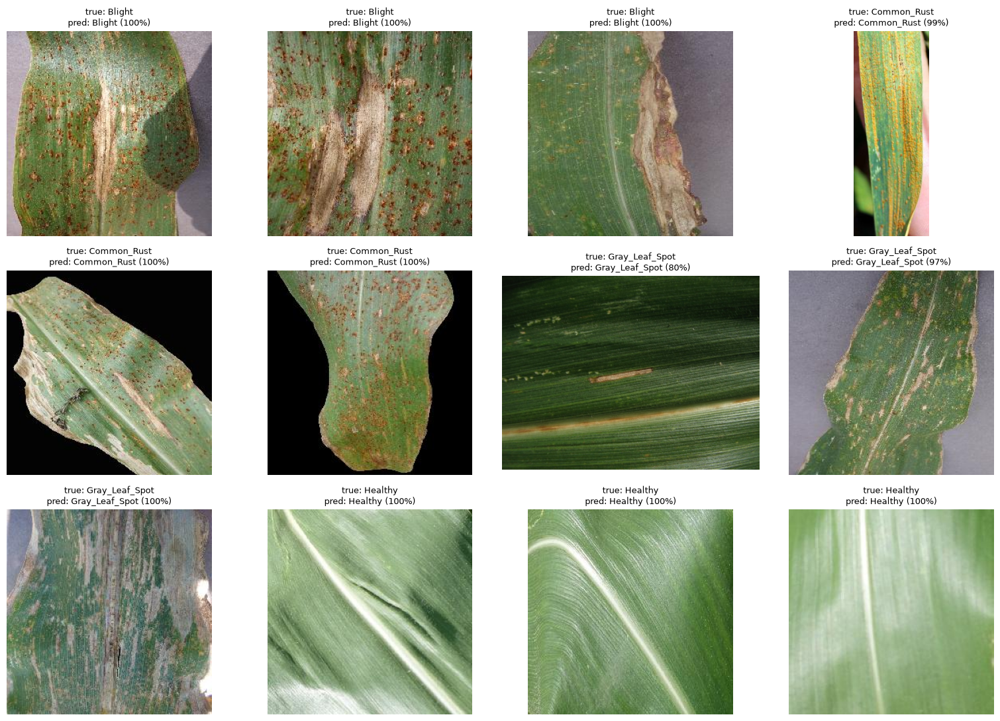

In [140]:
batch_images = []
for name in CLASS_NAMES:
    batch_images += sorted((DATASET_DIR / "test" / name).iterdir())[:3]

batch_results = predict_batch(batch_images)

fig, axes = plt.subplots(3, 4, figsize=(16, 11))
for ax, image_path, (predicted, confidence) in zip(axes.flat, batch_images, batch_results):
    ax.imshow(cv2.cvtColor(cv2.imread(str(image_path)), cv2.COLOR_BGR2RGB))
    ax.set_title(f"true: {image_path.parent.name}\npred: {predicted} ({confidence:.0%})", fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()

- Three images per class in one grid, so a single look covers all four diseases rather than one class only.
- The prediction under each photo is independent. A column where the labels mostly disagree with the titles is a class worth looking at closely.
- All twelve come from the test split, which is why they are a fair check on the final number rather than a memory exercise.
- Twelve images cannot move a 626-image accuracy, but they will catch a broken label mapping or an inverted colour channel immediately.

### 8.3 Manual QA

The check that actually matters: the final model over all 626 test images, every mistake printed, then the twelve it was most confident about. This is the number the section 9.3 report is built on.

Model:         Model A - YOLO26n-cls
Test accuracy: 95.05%  (595/626 correct)
Mistakes:      31

  Corn_Gray_Spot (303).JPG     true=Gray_Leaf_Spot  predicted=Blight          (100%)
  Corn_Common_Rust (14).jpg    true=Common_Rust     predicted=Blight          (100%)
  Corn_Blight (908).JPG        true=Blight          predicted=Common_Rust     (100%)
  Corn_Blight (203).JPG        true=Blight          predicted=Gray_Leaf_Spot  (100%)
  Corn_Gray_Spot (31).jpg      true=Gray_Leaf_Spot  predicted=Blight          (100%)
  Corn_Blight (672).JPG        true=Blight          predicted=Gray_Leaf_Spot  (100%)
  Corn_Gray_Spot (573).jpg     true=Gray_Leaf_Spot  predicted=Blight          (100%)
  Corn_Gray_Spot (562).jpg     true=Gray_Leaf_Spot  predicted=Blight          (99%)
  Corn_Gray_Spot (33).jpg      true=Gray_Leaf_Spot  predicted=Blight          (98%)
  Corn_Blight (270).JPG        true=Blight          predicted=Gray_Leaf_Spot  (97%)
  Corn_Blight (918).JPG        true=Blight          pred

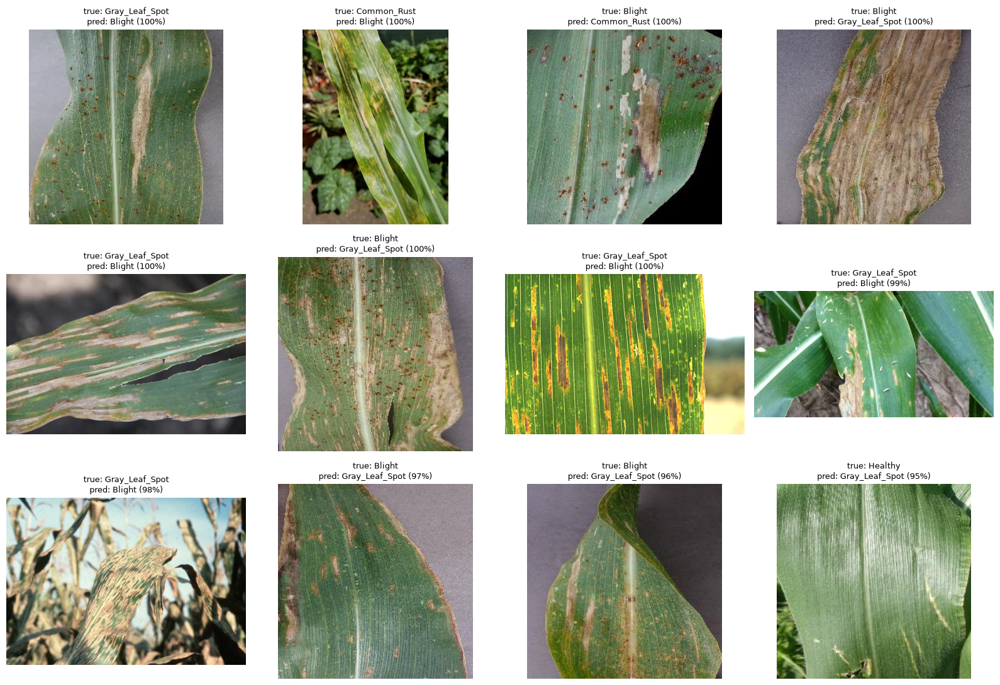

In [141]:
final_guesses = predict_batch(test_images)
final_records = [
    {"path": image_path, "true": true_label, "pred": predicted, "confidence": confidence}
    for image_path, true_label, (predicted, confidence) in zip(test_images, test_labels, final_guesses)
]
final_errors = [r for r in final_records if r["true"] != r["pred"]]
final_accuracy = 1 - len(final_errors) / len(final_records)

print(f"Model:         {FINAL_NAME}")
print(f"Test accuracy: {final_accuracy:.2%}  ({len(final_records) - len(final_errors)}/{len(final_records)} correct)")
print(f"Mistakes:      {len(final_errors)}\n")
for r in sorted(final_errors, key=lambda r: -r["confidence"])[:12]:
    print(f"  {r['path'].name:28s} true={r['true']:15s} predicted={r['pred']:15s} ({r['confidence']:.0%})")

fig, axes = plt.subplots(3, 4, figsize=(16, 11))
for ax, r in zip(axes.flat, sorted(final_errors, key=lambda r: -r["confidence"])[:12]):
    ax.imshow(cv2.cvtColor(cv2.imread(str(r["path"])), cv2.COLOR_BGR2RGB))
    ax.set_title(f"true: {r['true']}\npred: {r['pred']} ({r['confidence']:.0%})", fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()

- These are the images to look at before trusting the number. A single mislabelled photo skews the score for its whole class.
- Mistakes the model was 90% or more sure about are the interesting ones. The model genuinely disagrees with whoever labelled them.
- If most of these are visibly ambiguous, the data is the ceiling, and the fix is better labels or more photos.

### 8.4 Predict on a Single Custom Image

Point `CUSTOM_IMAGE` at any leaf photo on your machine to test the final model on data it has never seen - ideally one of your own field photos.

Image:      data/Healthy/Corn_Health (1).jpg
Predicted:  Healthy (100%)
  Blight            0.00%
  Common_Rust       0.00%
  Gray_Leaf_Spot    0.00%
  Healthy          100.00%


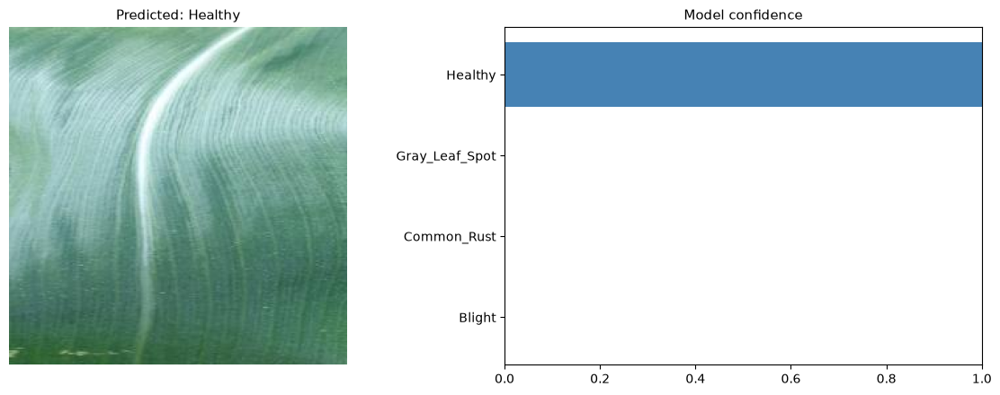

In [142]:
# Change this to any image path on your computer.
CUSTOM_IMAGE = "data/Healthy/Corn_Health (1).jpg"

if not Path(CUSTOM_IMAGE).exists():
    print(f"No image found at {CUSTOM_IMAGE}")
    print("Set CUSTOM_IMAGE to a valid path and re-run this cell.")
else:
    custom_image = cv2.imread(CUSTOM_IMAGE)
    custom_scores = predict_scores([Path(CUSTOM_IMAGE)])[0]
    custom_predicted = CLASS_NAMES[custom_scores.index(max(custom_scores))]

    print(f"Image:      {CUSTOM_IMAGE}")
    print(f"Predicted:  {custom_predicted} ({max(custom_scores):.0%})")
    for name, score in zip(CLASS_NAMES, custom_scores):
        print(f"  {name:16s} {score:6.2%}")

    fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
    ax[0].imshow(cv2.cvtColor(custom_image, cv2.COLOR_BGR2RGB))
    ax[0].set_title(f"Predicted: {custom_predicted}", fontsize=11)
    ax[0].axis("off")
    ax[1].barh(CLASS_NAMES, custom_scores, color="steelblue")
    ax[1].set_xlim(0, 1)
    ax[1].set_title("Model confidence", fontsize=11)
    plt.tight_layout()
    plt.show()

- This image is outside the split directory, so it is the closest thing here to a real farmer's photo rather than a curated dataset image.
- Healthy scores 100% and the other three are rounded to 0.00%. The softmax is decisive on a clean image, which is what you want before shipping to a phone.
- Change `CUSTOM_IMAGE` to any path and re-run. That single cell is the whole inference story: load the model, score the image, take the argmax.
- The score vector is printed rather than just the label, so a wrong call here can be read as the model being unsure between two diseases rather than simply mistaken.

## 9. Model Export & Deployment (Optional)

### 9.1 Export Model

ONNX is the format most other tools and phone apps can load. Needs one extra package. The CNN is saved as Keras instead, since exporting it to ONNX needs `tf2onnx` on top of `onnx`.

In [143]:
if BEST_IS_YOLO:
    try:
        import onnx  # checked up front so YOLO does not try to install it on its own
    except ImportError:
        onnx = None

    if onnx is None:
        print("ONNX export skipped - install the extra package with:  python3 -m pip install onnx")
    else:
        print(f"Exported to: {model_a.export(format='onnx', imgsz=IMGSZ)}")
else:
    print(f"Saved Keras model to: {cnn.export(str(MODELS_DIR / 'maize_disease_cnn.keras'))}")
    print("For ONNX from the CNN, install tf2onnx:  python3 -m pip install tf2onnx")

Ultralytics 8.4.165 🚀 Python-3.14.6 torch-2.14.0 CPU (Apple M4)
YOLO26s-cls summary (fused): 47 layers, 5,439,252 parameters, 0 gradients, 1.9 GFLOPs

PyTorch: starting from '/Users/willard/school/maize_disease/runs/classify/exp_b_larger_model/weights/best.pt' with input shape (1, 3, 256, 256) BCHW and output shape(s) (1, 4) (10.5 MB)

ONNX: starting export with onnx 1.23.1 opset 18...
ONNX: slimming with onnxslim 0.1.97...
ONNX: export success ✅ 0.7s, saved as '/Users/willard/school/maize_disease/runs/classify/exp_b_larger_model/weights/best.onnx' (20.8 MB)

Export complete (0.8s)
Results saved to /Users/willard/school/maize_disease/runs/classify/exp_b_larger_model/weights/best.onnx
Predict:         yolo predict task=classify model=/Users/willard/school/maize_disease/runs/classify/exp_b_larger_model/weights/best.onnx imgsz=256 
Validate:        yolo val task=classify model=/Users/willard/school/maize_disease/runs/classify/exp_b_larger_model/weights/best.onnx imgsz=256 data=data_balanc

- ONNX export needs a package Keras does not ship with, so the import is checked first and the cell prints the install command instead of failing halfway.
- The exported file is 20.8 MB against a 10.5 MB PyTorch checkpoint. ONNX stores the graph in full, which roughly doubles the size and buys framework independence.
- The input shape is fixed at 1x3x256x256, so any consumer has to resize the incoming photo to exactly 256x256 first.
- Netron is the quickest way to confirm the graph looks right without loading PyTorch.

### 9.2 Save Model Weights

Copies the final weights into `models/` under a clear name, so using the model later is one line:

```python
from ultralytics import YOLO
model = YOLO("models/maize_disease_yolo26n.pt")
```

If the CNN won section 5, the file is `models/maize_disease_cnn.keras` and it loads with `tf.keras.models.load_model` instead.

In [144]:
MODELS_DIR.mkdir(exist_ok=True)
final_path = MODELS_DIR / ("maize_disease_yolo26n.pt" if BEST_IS_YOLO else "maize_disease_cnn.keras")
shutil.copy2(FINAL_WEIGHTS, final_path)

print(f"Saved {final_path}  ({final_path.stat().st_size / 1e6:.1f} MB)")
if BEST_IS_YOLO:
    print(f"\nUse it with: YOLO('{final_path}')")
else:
    print(f"\nUse it with: tf.keras.models.load_model('{final_path}')")

Saved models/maize_disease_yolo26n.pt  (11.0 MB)

Use it with: YOLO('models/maize_disease_yolo26n.pt')


- The file is copied into `models/` under a fixed name, so the prediction code in section 8 can point at one path regardless of which experiment won.
- 11.0 MB is the yolo26s weights that 7.7 selected. The filename still says `yolo26n`, which is a leftover from the baseline - the contents are the larger variant.
- Copying rather than training means the deployed file is byte-identical to the one that produced the numbers in 8.3.
- Loading it back needs the same `imgsz=256` and the same alphabetical class order, both already fixed in the configuration cell.

### 9.3 Save Final Comparison Report

Writes everything worth keeping to `model_comparison.md`: the final model, its honest test score, the full Model A vs Model B table, and the section 7 experiment results.

In [145]:
report = [
    "# Maize Leaf Disease Classification - Final Report",
    "",
    f"**Final model:** {FINAL_NAME}  ({FINAL_WEIGHTS.name})",
    f"**Test accuracy:** {final_accuracy:.2%}  on {len(final_records)} held-out images",
    f"**Target accuracy:** {TARGET_ACCURACY:.0%} - {'reached' if final_accuracy >= TARGET_ACCURACY else 'not reached'}",
    f"**Seed:** {SEED}   **Classes:** {', '.join(CLASS_NAMES)}",
    "",
    "## Model Comparison (test split, sections 3-5)",
    "",
    "| Model | Accuracy | Precision | Recall | F1 | Train time | Size | Inference |",
    "|---|---|---|---|---|---|---|---|",
]
for m in (yolo_metrics, cnn_metrics):
    report.append(
        f"| {m['name']} | {m['accuracy']:.2%} | {m['precision']:.2%} | {m['recall']:.2%} | "
        f"{m['f1']:.2%} | {m['train_seconds'] / 60:.1f} min | {m['size_mb']:.1f} MB | {m['inference_ms']:.1f} ms |"
    )

report += [
    "",
    "## Error Reduction (validation split, section 7)",
    "",
    "| Configuration | Validation accuracy |",
    "|---|---|",
]
for name, (score, weights, family) in results.items():
    report.append(f"| {name} | {score:.2%} |")

report += [
    "",
    "## Inference",
    "",
    "```python",
    "from ultralytics import YOLO" if BEST_IS_YOLO else "import tensorflow as tf",
    f"model = YOLO('{final_path}')" if BEST_IS_YOLO else f"model = tf.keras.models.load_model('{final_path}')",
    f"result = model.predict('{CUSTOM_IMAGE}')" if BEST_IS_YOLO else "scores = model.predict(load_images([CUSTOM_IMAGE]))[0]",
    "```",
    "",
]

REPORT_PATH.write_text("\n".join(report))
print(f"Wrote {REPORT_PATH}  ({len(report)} lines)")

Wrote model_comparison.md  (30 lines)


- The report is generated from the same variables every other section used, so it cannot drift from the numbers in the notebook.
- Two tables rather than one, because the comparison in sections 3-5 is on the test split and the section 7 experiments are on validation. Mixing them in one table would be misleading.
- The target accuracy line records whether 96% was reached on the test split, not on the best validation figure that selected the model.
- The inference snippet at the end is the minimum needed to reproduce 8.4, including which class order the labels assume.